# Hypothesis Analysis: NASDAQ-100 vs. Bitcoin (Cross-Asset Trend Filtering Strategy)

**Project:** Cross-Asset Contradiction & Momentum Strategy  
**Asset Classes:** Equity Futures (NQ) & Cryptocurrency (BTC)  
**Timeframe:** 1-Minute Data  

### Executive Summary
This notebook tests the foundational hypothesis: **"Does immediate directional agreement between Bitcoin and NASDAQ-100 provide a profitable trading signal?"**

In this phase, we strip away all technical indicators (SMA, ATR) to evaluate the raw predictive power of the cross-asset relationship.

### Structure:
1.  **Data Engine:** Synchronization of NQ and BTC timelines.
2.  **Statistical Analysis:** Global Correlation Matrix, Rolling Correlation, and Hourly Heatmaps.
3.  **Strategy Engine (Naked):** Pure momentum strategy based solely on candle alignment (No filters).
4.  **Performance Analysis:** P&L by Hour, Equity Curve, and 3D Optimization Landscapes.

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter
import matplotlib.colors as mcolors
import pandas_market_calendars as mcal

# --- CONFIGURATION ---
FILE_BTC = r"C:\Python\studia\ML_project\2_Phase\ENGINE_BINANCE_BTC_2024-01-01_to_2025_12_05.csv"
FILE_NQ = r"C:\Python\studia\ML_project\2_Phase\ENGINE_Nasdaq_1_minute_data_2024-01-01_to_2025-12-05.csv"

# Hard Close Time (Safety Mechanism)
CLOSE_HOUR = 21
CLOSE_MINUTE = 55

# Settings
pd.set_option('display.max_columns', None)
print("Environment Configured.")

Environment Configured.


## 1. Data Engine
The `DataEngine` class is responsible for loading raw CSV files, standardizing column names, synchronizing timestamps (to handle different timezones), and merging the datasets into a single timeline.

In [52]:
class DataEngine:
    def __init__(self, path_btc, path_nq):
        self.path_btc = path_btc
        self.path_nq = path_nq

    def load_data(self):
        try:
            df_btc = pd.read_csv(self.path_btc, sep=None, engine='python')
            df_nq = pd.read_csv(self.path_nq, sep=None, engine='python')
        except FileNotFoundError:
            print("ERROR: Files not found.")
            return None

        def clean(df, suffix):
            df.columns = [c.strip().lower() for c in df.columns]
            rename = {}
            for c in df.columns:
                if 'time' in c and 'utc' not in c: rename[c] = 'time'
                elif 'close' in c: rename[c] = f'close_{suffix}'
                elif 'open' in c: rename[c] = f'open_{suffix}'
                elif 'high' in c: rename[c] = f'high_{suffix}'
                elif 'low' in c: rename[c] = f'low_{suffix}'
            df = df.rename(columns=rename)
            if 'time' in df.columns:
                df['time'] = df['time'].astype('int64')
                df['datetime'] = pd.to_datetime(df['time'], unit='s') + pd.Timedelta(hours=1)
            return df

        df_btc = clean(df_btc, 'btc')
        df_nq = clean(df_nq, 'nq')

        merged = pd.merge(df_btc, df_nq, on='datetime', how='inner', suffixes=('', '_del'))
        merged = merged.loc[:, ~merged.columns.str.endswith('_del')]
        merged.set_index('datetime', inplace=True)
        merged.sort_index(inplace=True)
        merged = merged[merged.index.dayofweek < 5] 
        merged.dropna(inplace=True)
        
        # Returns & Correlation (Needed for EDA Charts)
        merged['ret_btc'] = merged['close_btc'].pct_change()
        merged['ret_nq'] = merged['close_nq'].pct_change()
        merged['rolling_corr'] = merged['ret_btc'].rolling(60).corr(merged['ret_nq'])
        
        merged.dropna(inplace=True)
        print(f"Data Loaded: {len(merged)} candles.")
        return merged

# Load Data immediately for Analysis
engine = DataEngine(FILE_BTC, FILE_NQ)
market_data = engine.load_data()

Data Loaded: 677514 candles.


## 2. Statistical Analysis
In this cell we will be computing plots of global correlation matrix, rolling correlation and hourly correlation heatmap (with division of particular days of the week).

Generating Statistical Analysis Charts...


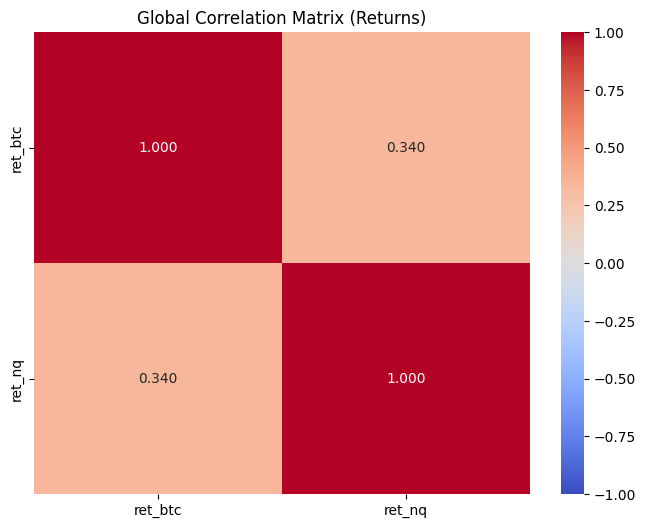

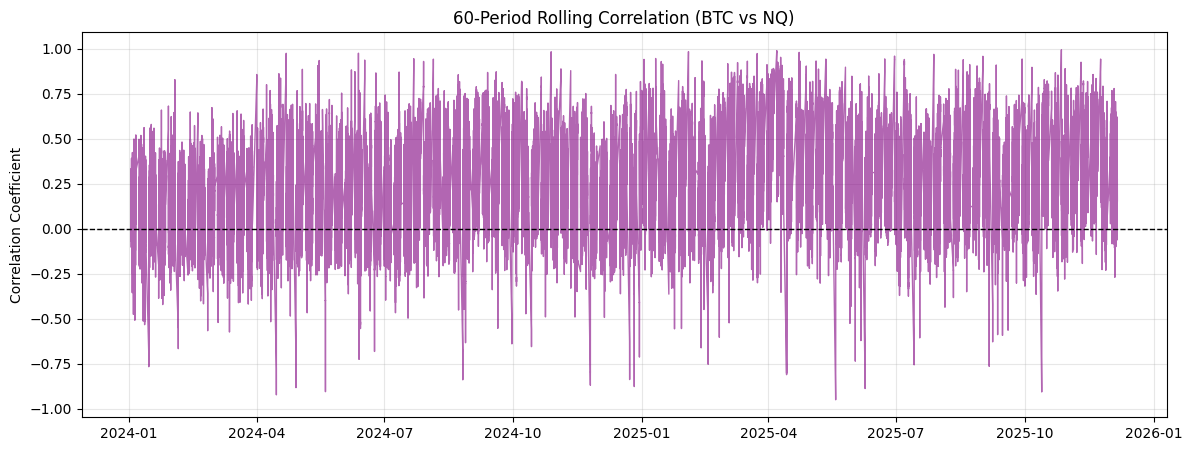

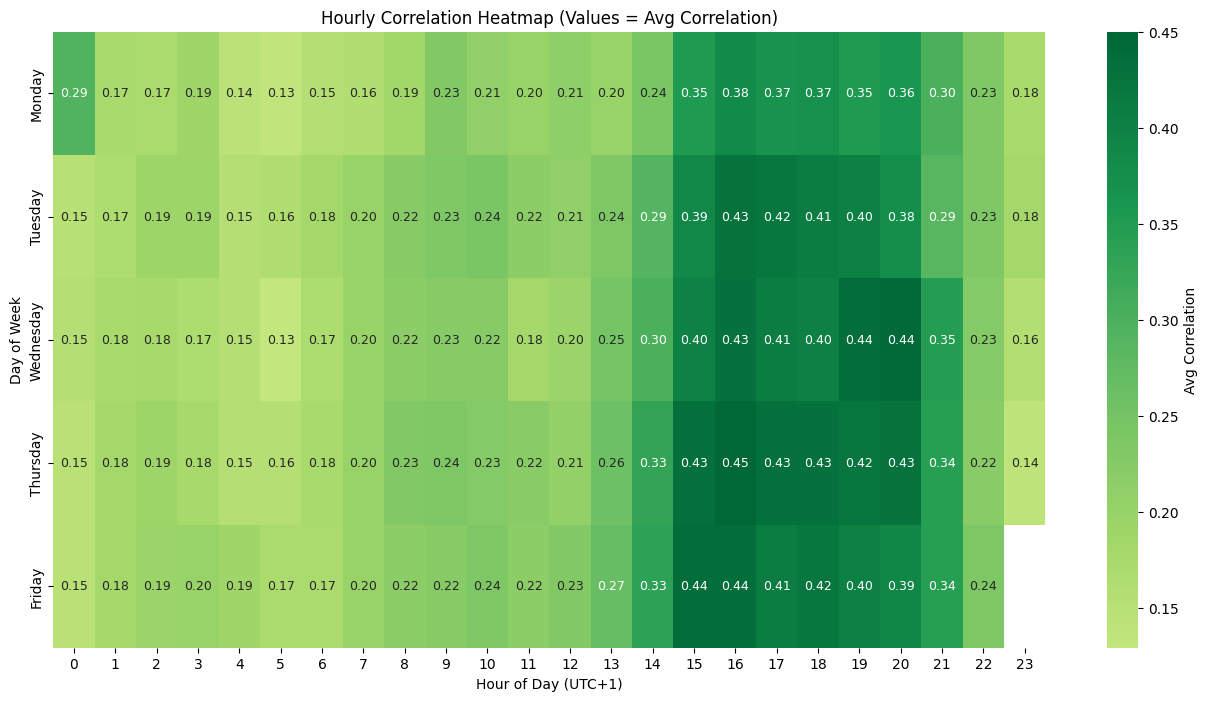

In [53]:
if market_data is not None:
    print("Generating Statistical Analysis Charts...")
    
    # 1. Global Correlation Matrix (Returns)
    plt.figure(figsize=(8, 6))
    corr_matrix = market_data[['ret_btc', 'ret_nq']].corr()
    
    # annot=True adds numerical values
    sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap='coolwarm', vmin=-1, vmax=1)
    plt.title('Global Correlation Matrix (Returns)')
    plt.show()

    # 2. Rolling Correlation Plot
    plt.figure(figsize=(14, 5))
    plt.plot(market_data.index, market_data['rolling_corr'], color='purple', alpha=0.6, linewidth=1)
    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    plt.title('60-Period Rolling Correlation (BTC vs NQ)')
    plt.ylabel('Correlation Coefficient')
    plt.grid(True, alpha=0.3)
    plt.show()

    # 3. Hourly Correlation Heatmap (Day of Week vs Hour)
    # Prepare data for heatmap
    df_heat = market_data.copy()
    df_heat['hour'] = df_heat.index.hour
    df_heat['day'] = df_heat.index.day_name()
    
    # Order days logically
    days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
    
    # Create pivot table (Day vs Hour)
    pivot_corr = df_heat.groupby(['day', 'hour'])['rolling_corr'].mean().unstack()
    pivot_corr = pivot_corr.reindex(days_order)

    plt.figure(figsize=(16, 8)) 
    
    # annot=True: Show values
    # fmt=".3f": Format to 2 decimal places
    sns.heatmap(pivot_corr, cmap='RdYlGn', center=0, 
                annot=True, fmt=".2f", annot_kws={"size": 9},
                cbar_kws={'label': 'Avg Correlation'})
    
    plt.title('Hourly Correlation Heatmap (Values = Avg Correlation)')
    plt.xlabel('Hour of Day (UTC+1)')
    plt.ylabel('Day of Week')
    plt.show()

## 3. Naked Strategy Engine
This strategy executes trades based **only** on the directional agreement between BTC and NQ (which will be further enhanced by adding indicators)

* Hard Time Close (22:45) and Gap Protection (Risk Management is mandatory for valid backtesting).

In [63]:
import pandas_market_calendars as mcal
import pandas as pd
import numpy as np

class StrategyEngine:
    def __init__(self, data):
        self.df = data.copy()
        if 'datetime' not in self.df.columns:
            self.df = self.df.reset_index()

        print("Inicjalizacja pancernego kalendarza (Early Closes & Holidays)...")
        
        # 1. Pobieramy kalendarz NYSE (obowiązuje dla NQ)
        nyse = mcal.get_calendar('NYSE')
        schedule = nyse.schedule(start_date=self.df['datetime'].min(), 
                                 end_date=self.df['datetime'].max())
        
        # 2. Konwertujemy godziny zamknięcia na czas Twoich danych (UTC+1 / Polska)
        # mcal zwraca UTC, dodajemy 1h żeby pasowało do Twojego 'datetime' w pliku
        schedule['close_pl'] = schedule['market_close'].dt.tz_convert('UTC') + pd.Timedelta(hours=1)
        schedule['close_pl'] = schedule['close_pl'].dt.tz_localize(None) # Usuwamy info o strefie dla łatwego porównania
        
        # Tworzymy słownik {Data: Czas_Zamknięcia} dla błyskawicznego sprawdzania w pętli
        self.market_closes = schedule['close_pl'].to_dict()
        
        # 3. Pre-calculating kierunków (Sygnały)
        self.df['dir_btc'] = np.sign(self.df['close_btc'] - self.df['open_btc'])
        self.df['dir_nq'] = np.sign(self.df['close_nq'] - self.df['open_nq'])

    def run(self):
        trades = []
        position = 0
        entry_price = 0.0
        entry_time = None

        # Konwersja na listę słowników (maksymalna prędkość pętli)
        data = self.df.to_dict('records')

        for i in range(len(data) - 1):
            row = data[i]
            next_row = data[i+1] # Look-ahead bias zachowany
            curr_time = row['datetime']
            
            # --- LOGIKA ZAMYKANIA (SAFETY) ---
            day_key = curr_time.normalize()
            
            is_exit_time = False
            # A. Czy dziś jest giełda otwarta?
            if day_key not in self.market_closes:
                is_exit_time = True
            else:
                # B. Czy jesteśmy 5 min przed zamknięciem (uwzględnia Early Closes o 19:00!)
                m_close = self.market_closes[day_key]
                if curr_time >= (m_close - pd.Timedelta(minutes=5)):
                    is_exit_time = True
            
            # C. Bezpiecznik Piątkowy: 21:15 (Kluczowy na weekendy)
            if curr_time.weekday() == 4: # Piątek
                if (curr_time.hour == 21 and curr_time.minute >= 15) or curr_time.hour > 21:
                    is_exit_time = True

            # Sygnały
            dir_btc = row['dir_btc']
            dir_nq = row['dir_nq']

            # =========================================
            #           LOGIKA WYJŚCIA (EXIT)
            # =========================================
            if position != 0:
                is_divergence = (dir_btc != dir_nq)
                is_reversal = (dir_btc == -position) and (dir_nq == -position)

                if is_exit_time or is_divergence or is_reversal:
                    exit_price = row['close_nq']
                    pnl = (exit_price - entry_price) * position
                    
                    reason = "Divergence"
                    if is_exit_time: reason = "Market Close/Friday"
                    elif is_reversal: reason = "Reversal"

                    trades.append({
                        'Entry Time': entry_time,
                        'Exit Time': curr_time,
                        'Type': "LONG" if position == 1 else "SHORT",
                        'Entry Price': entry_price,
                        'Exit Price': exit_price,
                        'Points': pnl,
                        'Duration (min)': (curr_time - entry_time).total_seconds() / 60.0,
                        'Reason': reason
                    })
                    position = 0
                    if is_exit_time: continue

            # =========================================
            #           LOGIKA WEJŚCIA (ENTRY)
            # =========================================
            if position == 0 and not is_exit_time:
                # Sygnał: Zgodność BTC i NQ
                if dir_btc == 1 and dir_nq == 1:
                    position = 1
                    entry_price = next_row['open_nq'] # Look-ahead
                    entry_time = next_row['datetime']
                elif dir_btc == -1 and dir_nq == -1:
                    position = -1
                    entry_price = next_row['open_nq'] # Look-ahead
                    entry_time = next_row['datetime']

        return pd.DataFrame(trades)

## 4. Execution Cells

In [64]:
if market_data is not None:
    strat = StrategyEngine(market_data)
    results = strat.run()
    
    if not results.empty:
        overnight_err = (results['Entry Time'].dt.date != results['Exit Time'].dt.date).sum()
        print(f"\n=== NAKED STRATEGY RESULTS ===")
        print(f"Total Trades:      {len(results)}")
        print(f"Total Net Points:  {results['Points'].sum():.2f}")
        print(f"Overnight Errors:  {overnight_err}")
    else:
        print("No trades.")

Inicjalizacja pancernego kalendarza (Early Closes & Holidays)...

=== NAKED STRATEGY RESULTS ===
Total Trades:      252223
Total Net Points:  14438.86
Overnight Errors:  0


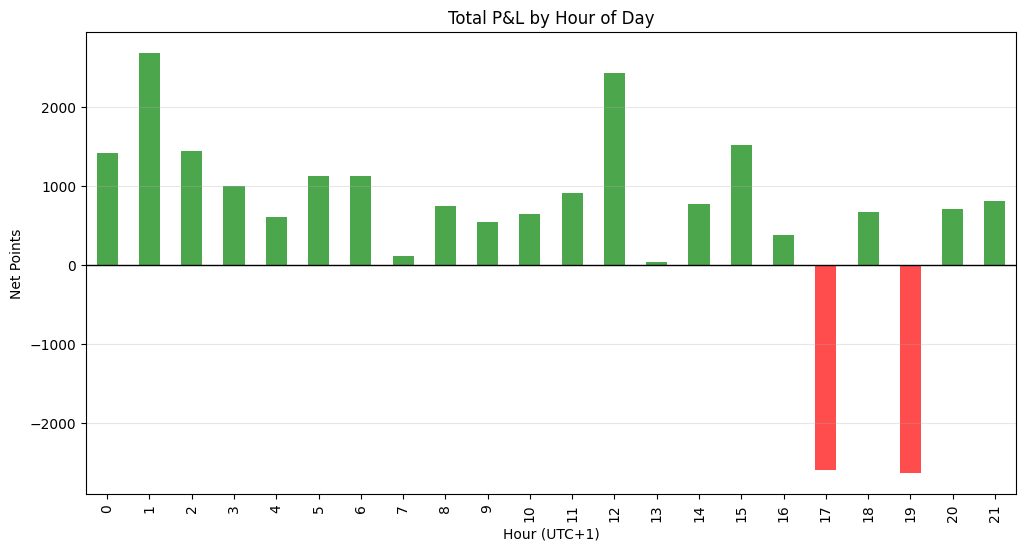

In [65]:
if 'results' in locals() and not results.empty:
    results['Hour'] = results['Entry Time'].dt.hour
    hourly_pnl = results.groupby('Hour')['Points'].sum()
    
    plt.figure(figsize=(12, 6))
    hourly_pnl.plot(kind='bar', color=np.where(hourly_pnl > 0, 'green', 'red'), alpha=0.7)
    plt.title('Total P&L by Hour of Day')
    plt.ylabel('Net Points')
    plt.xlabel('Hour (UTC+1)')
    plt.axhline(0, color='black', linewidth=1)
    plt.grid(axis='y', alpha=0.3)
    plt.show()

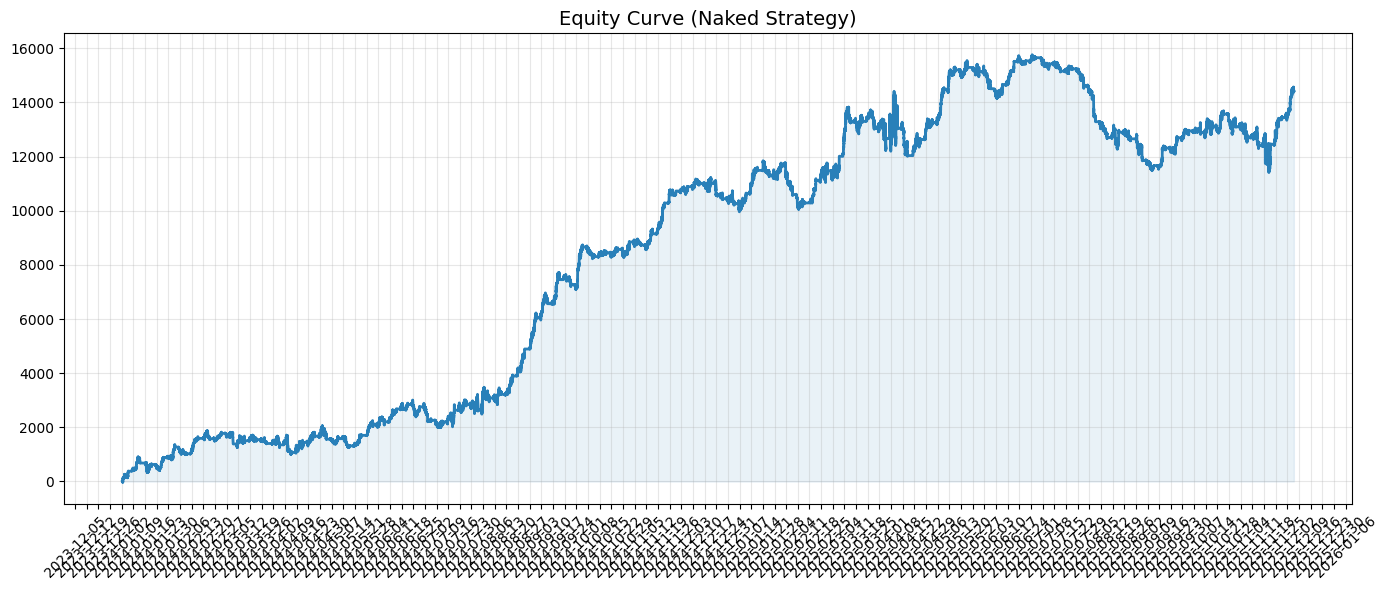

In [66]:
if 'results' in locals() and not results.empty:
    plt.figure(figsize=(14, 6))
    results['Equity'] = results['Points'].cumsum()
    plt.plot(results['Exit Time'], results['Equity'], color='#2980b9', linewidth=2)
    plt.fill_between(results['Exit Time'], results['Equity'], 0, alpha=0.1, color='#2980b9')
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.title('Equity Curve (Naked Strategy)', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Generating Micro-Duration 3D Analysis...


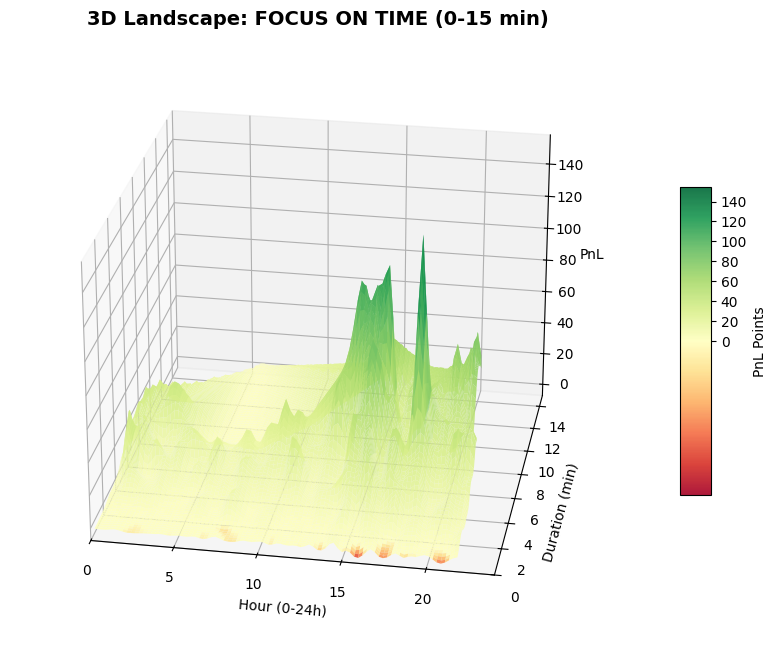

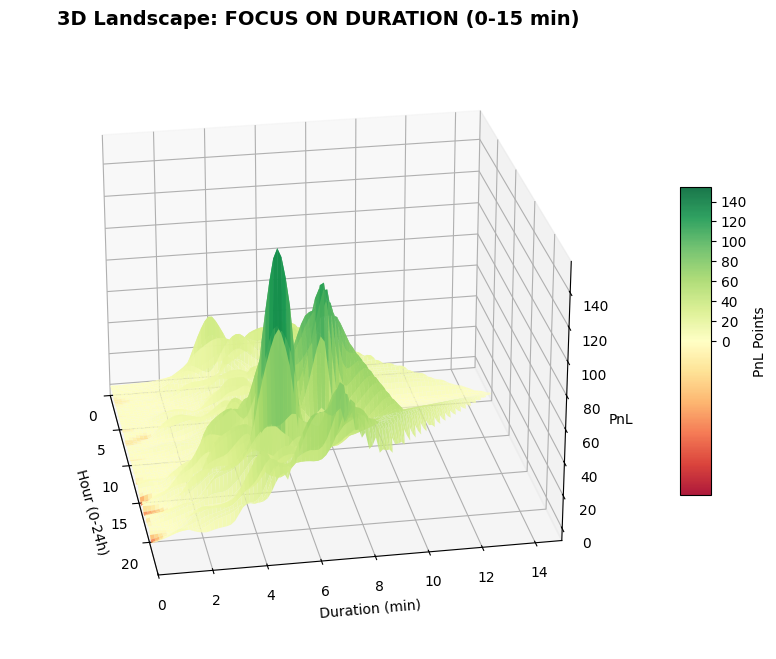

In [67]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter

# Upewniamy się, że mamy wyniki
if 'results' in locals() and not results.empty:
    print("Generating Micro-Duration 3D Analysis...")

    # --- ZMIANA: Skupiamy się na BARDZO KRÓTKICH transakcjach (do 15 min) ---
    limit_dur = 15.0 
    df_3d = results[results['Duration (min)'] <= limit_dur].copy()
    
    if len(df_3d) > 5:
        df_3d['Entry Time'] = pd.to_datetime(df_3d['Entry Time'])
        df_3d['Hour_Float'] = df_3d['Entry Time'].dt.hour + df_3d['Entry Time'].dt.minute / 60.0
        
        x = df_3d['Hour_Float']
        y = df_3d['Duration (min)']
        z = df_3d['Points']

        # Siatka dopasowana do zakresu 0-8 min
        xi = np.linspace(0, 24, 100)
        yi = np.linspace(0, limit_dur, 100) 
        xi, yi = np.meshgrid(xi, yi)

        # Interpolacja
        zi = griddata((x, y), z, (xi, yi), method='linear')
        
        # Wygładzanie (zmniejszone sigma dla zachowania detali)
        zi_filled = np.nan_to_num(zi, nan=0.0)
        zi_smooth = gaussian_filter(zi_filled, sigma=1.0)
        zi_smooth[np.isnan(zi)] = np.nan 

        # Naprawa Kolorów (Czerwony widoczny)
        valid_vals = zi_smooth[~np.isnan(zi_smooth)]
        if len(valid_vals) > 0:
            data_min = valid_vals.min()
            data_max = valid_vals.max()
            norm = mcolors.TwoSlopeNorm(vmin=min(data_min, -5.0), vcenter=0, vmax=max(data_max, 5.0))
        else:
            norm = None

        # --- WYKRES 1: FOCUS ON TIME (0-8 min) ---
        fig1 = plt.figure(figsize=(14, 8))
        ax1 = fig1.add_subplot(111, projection='3d')
        
        surf1 = ax1.plot_surface(xi, yi, zi_smooth, cmap='RdYlGn', norm=norm, 
                               antialiased=True, alpha=0.9, rstride=1, cstride=1, 
                               edgecolor='none')
        
        ax1.set_title(f'3D Landscape: FOCUS ON TIME (0-{int(limit_dur)} min)', fontsize=14, fontweight='bold')
        ax1.set_xlabel('Hour (0-24h)')
        ax1.set_ylabel('Duration (min)')
        ax1.set_zlabel('PnL')
        ax1.set_xlim(0, 24)
        ax1.set_ylim(0, limit_dur) # Sztywne ustawienie limitu osi Y do 8 min
        
        ax1.view_init(elev=25, azim=-80) 
        ax1.dist = 9
        
        fig1.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10, label='PnL Points')
        plt.show()

        # --- WYKRES 2: FOCUS ON DURATION (0-8 min) ---
        fig2 = plt.figure(figsize=(14, 8))
        ax2 = fig2.add_subplot(111, projection='3d')
        
        surf2 = ax2.plot_surface(xi, yi, zi_smooth, cmap='RdYlGn', norm=norm, 
                               antialiased=True, alpha=0.9, rstride=1, cstride=1, 
                               edgecolor='none')
        
        ax2.set_title(f'3D Landscape: FOCUS ON DURATION (0-{int(limit_dur)} min)', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Hour (0-24h)')
        ax2.set_ylabel('Duration (min)')
        ax2.set_zlabel('PnL')
        ax2.set_xlim(0, 24)
        ax2.set_ylim(0, limit_dur)
        
        ax2.view_init(elev=25, azim=-10)
        ax2.dist = 9
        
        fig2.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10, label='PnL Points')
        plt.show()

    else:
        print(f"Za mało danych w zakresie 0-{limit_dur} min.")
else:
    print("Brak wyników (results).")

## Top trades analysis

In [68]:
if 'results' in locals() and not results.empty:
    longest = results.sort_values(by='Duration (min)', ascending=False).head(100)
    print("=== TOP 100 LONGEST TRADES ===")
    print(longest[['Entry Time', 'Type', 'Duration (min)', 'Points', 'Reason']].to_string(index=False))

=== TOP 100 LONGEST TRADES ===
         Entry Time  Type  Duration (min)  Points     Reason
2024-07-11 05:35:00  LONG            15.0    1.00   Reversal
2024-10-24 17:24:00  LONG            10.0   49.50   Reversal
2024-05-28 19:29:00 SHORT             9.0   54.50 Divergence
2025-04-21 14:53:00 SHORT             8.0   87.12   Reversal
2025-08-22 03:53:00 SHORT             8.0   20.50 Divergence
2024-05-31 01:52:00  LONG             8.0   20.87 Divergence
2025-07-11 01:11:00 SHORT             8.0   53.38 Divergence
2025-05-12 05:25:00 SHORT             8.0   -0.25   Reversal
2025-10-07 11:07:00  LONG             8.0   13.12   Reversal
2025-09-30 19:06:00  LONG             7.0   33.75 Divergence
2024-05-14 19:09:00  LONG             7.0   35.12 Divergence
2024-09-03 10:55:00 SHORT             7.0   19.25   Reversal
2025-10-10 15:56:00 SHORT             7.0  273.00 Divergence
2025-01-08 16:08:00 SHORT             7.0  120.38 Divergence
2025-10-02 06:17:00 SHORT             7.0    4.13   Re